In [1]:
from qiskit.quantum_info import random_unitary
from qiskit.circuit.library import UnitaryGate
from qiskit import QuantumCircuit, transpile
from qiskit_aer.noise import NoiseModel, depolarizing_error, QuantumError
from qiskit.quantum_info import Operator
import numpy as np
from math import comb
from qiskit_aer import AerSimulator
from mitigation_utils.error_mitigation import invert_depolarizing_noise, projection_simplex_sort
from mitigation_utils.bitstring_processing import compose_counts, counts_to_probs, pauli_expectation_value
import math
import matplotlib.pyplot as plt
from mitigation_utils.pauli_twirling import apply_cx_pauli_twirling
from mitigation_utils.bitstring_processing import compose_counts, counts_to_probs, pauli_expectation_value
from qiskit.circuit.random import random_circuit
import random
import pickle

In [2]:
random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)

In [3]:
def generate_transpiled_haar_random_circuit(num_qubits, seed=None):
    haar_random_matrix = random_unitary(2**num_qubits,seed=seed)
    haar_random_gate = UnitaryGate(haar_random_matrix)
    qc = QuantumCircuit(num_qubits)
    qc.append(haar_random_gate, list(range(num_qubits)))
    transpiled_circ = transpile(qc, basis_gates=['cx', 'x', 'sx', 'rz', 'id'], optimization_level=3)
    transpiled_circ.save_state()
    return transpiled_circ

In [4]:
def count_cx(target_pair, circuit):
    cx_count = 0
    for instruction in circuit.data:
        if target_pair[0] in [qubit._index for qubit in instruction.qubits] and target_pair[1] in [qubit._index for qubit in instruction.qubits] and instruction.operation.name == 'cx':
            cx_count += 1
    return cx_count

def count_cx_all_pairs(circuit, qubit_count):
    cx_counts_by_pair = []
    for q0 in range(qubit_count):
        for q1 in range(q0+1, qubit_count):
            cx_counts_by_pair.append(count_cx([q0,q1], circuit))
    return np.array(cx_counts_by_pair)

In [5]:
num_qubits = 6
num_circuits = 10
depth = 150
haar_random_circuits = [generate_transpiled_haar_random_circuit(num_qubits, seed=i) for i in range(num_circuits)]

In [6]:
# populate G matrix
def get_g_matrix(circuit):
    G = np.zeros(shape=(num_qubits, num_qubits))
    for q0 in range(num_qubits):
        for q1 in range(q0+1, num_qubits):
            G[q0,q1] = count_cx([q0,q1], circuit)
            G[q1,q0] = G[q0,q1]
    return G

In [7]:
def offdiag_variance(F, E, G):
    """Variance of E[F(i),F(j)]**G[i,j] over i != j."""
    X = E[F][:, F] ** G
    n = len(F)
    
    mask = ~np.eye(n, dtype=bool)
    vals = X[mask]
    
    return np.var(vals)
    #return np.ptp(vals)

def offdiag_totals(F, E, G):
    """Variance of E[F(i),F(j)]**G[i,j] over i != j."""
    X = E[F][:, F] ** G
    n = len(F)
    
    mask = ~np.eye(n, dtype=bool)
    vals = X[mask]
    
    #return np.var(vals)
    return vals


def simulated_annealing(E, G, steps=5000, T0=1.0, seed=None):
    """
    Minimize off-diagonal variance using simple simulated annealing.
    Suitable for n < 10.
    """
    if seed is not None:
        np.random.seed(seed)

    n = len(E)
    F = np.random.permutation(n)
    best_F = F.copy()
    best_val = offdiag_variance(F, E, G)

    for t in range(steps):
        T = T0 * (1 - t / steps)  # linear cooling
        
        # propose swap
        i, j = np.random.choice(n, 2, replace=False)
        F_new = F.copy()
        F_new[i], F_new[j] = F_new[j], F_new[i]
        
        new_val = offdiag_variance(F_new, E, G)
        delta = new_val - best_val
        
        # accept move?
        if delta < 0 or np.random.rand() < np.exp(-delta / max(T, 1e-12)):
            F = F_new
            if new_val < best_val:
                best_val = new_val
                best_F = F.copy()

    best_mapping = {logical_qubit:int(best_F[logical_qubit]) for logical_qubit in range(num_qubits)}
    return best_mapping, best_val

In [8]:
def noisy_simulator(twoq_depolarizing_errors, num_qubits):
    index = 0
    noise_model = NoiseModel()

    for q0 in range(num_qubits):
        for q1 in range(q0+1, num_qubits):
            cx_depolarizing_error = depolarizing_error(twoq_depolarizing_errors[index],2)
            noise_model.add_quantum_error(cx_depolarizing_error, ['cx'], [q0, q1])
            noise_model.add_quantum_error(cx_depolarizing_error, ['cx'], [q1, q0])
            index += 1
    return AerSimulator(noise_model=noise_model, method='density_matrix')



In [9]:
def reindex_circuit(circ_orig, new_qubit_map):
    circ_new = QuantumCircuit(num_qubits)
    for instruction in circ_orig.data:
        op = instruction.operation
        # Get old qubits and map them to new indices
        old_qubits = instruction.qubits
        new_qubits_indices = [new_qubit_map[q._index] for q in old_qubits]
        if op.name != 'measure':
            circ_new.append(op, new_qubits_indices, instruction.clbits)
    return circ_new

In [10]:
def count_equivalent_cx_gates(circuit, pair, E, target_lambda):
    num_gates = count_cx(pair, circuit)
    pair_lambda = E[pair[0], pair[1]]
    equivalent_gate_count = num_gates * np.log(pair_lambda) / np.log(target_lambda)
    return equivalent_gate_count
def count_total_equivalent_cx_gates(circuit, E, target_lambda):
    equivalent_gate_count = 0
    for q0 in range(num_qubits):
        for q1 in range(q0 + 1, num_qubits):
            equivalent_gate_count += count_equivalent_cx_gates(circuit, (q0, q1), E, target_lambda)
    return equivalent_gate_count

In [11]:
def hellinger_distance(P, Q):
    keys = set(P.keys()).union(Q.keys())
    return math.sqrt(
        0.5 * sum(
            (math.sqrt(P.get(k, 0.0)) - math.sqrt(Q.get(k, 0.0)))**2
            for k in keys
        )
    )

In [12]:
np.std(count_cx_all_pairs(haar_random_circuits[1], num_qubits))

np.float64(148.28480104927215)

In [14]:
all_costs = []
unmitigated_infidelities = []
mitigated_infidelities = []
mitigated_infidelities_no_ri = []
E_matrices = []
error_ranges = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01]
for error_range in error_ranges:
    print(error_range)
    twoq_depolarizing_errors = error_range * np.random.rand(comb(num_qubits, 2))
    index = 0
    E = np.zeros(shape=(num_qubits, num_qubits))
    for q0 in range(num_qubits):
        for q1 in range(q0 + 1, num_qubits):
            E[q0,q1] = 1 - twoq_depolarizing_errors[index]
            E[q1,q0] = 1 - twoq_depolarizing_errors[index]
            # Depolarizing quantum error
            cx_depolarizing_error = depolarizing_error(twoq_depolarizing_errors[index], 2)
            index += 1
    E_matrices.append(E)
    ideal_simulator = AerSimulator(noise_model=None, method="density_matrix")

    haar_random_circuits_layout_selected = []
    annealing_objectives = []
    for circuit in haar_random_circuits:
        best_mapping, best_cost = simulated_annealing(E, get_g_matrix(circuit))
        haar_random_circuits_layout_selected.append(reindex_circuit(circuit, best_mapping))
        annealing_objectives.append(best_cost)
    all_costs.append(np.array(annealing_objectives))

    chosen_lambda = 0.999
    twirls=1
    estimated_global_depolarizing_parameter = (chosen_lambda ** (15/16))
    index = 0


    simulator = noisy_simulator(twoq_depolarizing_errors, num_qubits)


    probs_mitigated_per_circuit = []
    for circuit in haar_random_circuits_layout_selected:
        print(index)
        twirled_circuits = [apply_cx_pauli_twirling(circuit, twirling_seed) for twirling_seed in range(twirls)]
        result = simulator.run(twirled_circuits).result()
        probs_per_circuit = [np.real(np.diag(result.data(i)['density_matrix'])) for i in range(twirls)]
        probs_per_circuit = [{f"{i:0{num_qubits}b}":prob for i, prob in enumerate(probs)} for probs in probs_per_circuit]
        probs = counts_to_probs(compose_counts(probs_per_circuit))
        pseudo_probs = invert_depolarizing_noise(probs, 1 - estimated_global_depolarizing_parameter, count_total_equivalent_cx_gates(circuit, E, chosen_lambda))
        probs_mitigated_per_circuit.append(projection_simplex_sort(pseudo_probs))
        index += 1
    result = ideal_simulator.run(haar_random_circuits_layout_selected).result()
    ideal_probs_per_circuit = [np.real(np.diag(result.data(i)['density_matrix'])) for i in range(num_circuits)]
    ideal_probs_per_circuit = [{f"{i:0{num_qubits}b}":prob for i, prob in enumerate(probs)} for probs in ideal_probs_per_circuit]
    mitigated_infidelity = np.array([hellinger_distance(ideal_probs_per_circuit[i], probs_mitigated_per_circuit[i]) for i in range(num_circuits)])
    mitigated_infidelities.append(mitigated_infidelity)
    

    probs_mitigated_per_circuit_no_ri = []
    for circuit in haar_random_circuits:
        print(index)
        twirled_circuits = [apply_cx_pauli_twirling(circuit, twirling_seed) for twirling_seed in range(twirls)]
        result = simulator.run(twirled_circuits).result()
        probs_per_circuit = [np.real(np.diag(result.data(i)['density_matrix'])) for i in range(twirls)]
        probs_per_circuit = [{f"{i:0{num_qubits}b}":prob for i, prob in enumerate(probs)} for probs in probs_per_circuit]
        probs = counts_to_probs(compose_counts(probs_per_circuit))
        pseudo_probs = invert_depolarizing_noise(probs, 1 - estimated_global_depolarizing_parameter, count_total_equivalent_cx_gates(circuit, E, chosen_lambda))
        probs_mitigated_per_circuit_no_ri.append(projection_simplex_sort(pseudo_probs))
        index += 1
    result = ideal_simulator.run(haar_random_circuits).result()
    ideal_probs_per_circuit_no_ri = [np.real(np.diag(result.data(i)['density_matrix'])) for i in range(num_circuits)]
    ideal_probs_per_circuit_no_ri = [{f"{i:0{num_qubits}b}":prob for i, prob in enumerate(probs)} for probs in ideal_probs_per_circuit_no_ri]
    mitigated_infidelity_no_ri = np.array([hellinger_distance(ideal_probs_per_circuit_no_ri[i], probs_mitigated_per_circuit_no_ri[i]) for i in range(num_circuits)])
    mitigated_infidelities_no_ri.append(mitigated_infidelity_no_ri)
    
    result = simulator.run(haar_random_circuits).result()
    probs_per_circuit_unmitigated = [np.real(np.diag(result.data(i)['density_matrix'])) for i in range(num_circuits)]
    probs_per_circuit_unmitigated = [{f"{i:0{num_qubits}b}":prob for i, prob in enumerate(probs)} for probs in probs_per_circuit_unmitigated]
    unmitigated_infidelity = np.array([hellinger_distance(ideal_probs_per_circuit_no_ri[i], probs_per_circuit_unmitigated[i]) for i in range(num_circuits)])
    unmitigated_infidelities.append(unmitigated_infidelity)





0.001
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0.002
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0.003
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0.004
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0.005
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0.006
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0.007
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0.008
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0.009
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0.01
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [15]:
all_default_costs = []
for i, error_range in enumerate(error_ranges):
    # we can just use one circuit because all of them compile into the exact same structure
    all_default_costs.append(offdiag_variance(np.array(range(num_qubits)), E_matrices[i], get_g_matrix(haar_random_circuits[1])))

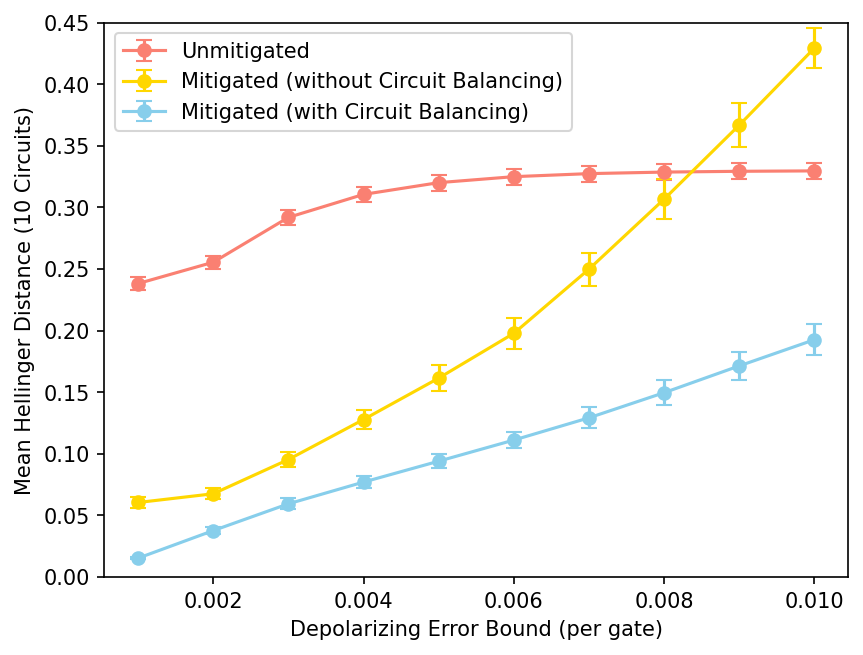

In [16]:
error_ranges = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01]
fig = plt.figure(dpi=150)
plt.errorbar(error_ranges, [np.mean(infidelity) for infidelity in unmitigated_infidelities], yerr=[np.std(infidelity)/np.sqrt(num_circuits) for infidelity in unmitigated_infidelities], fmt='o-', capsize=4, color = 'salmon', label='Unmitigated')
plt.errorbar(error_ranges, [np.mean(infidelity) for infidelity in mitigated_infidelities_no_ri], yerr=[np.std(infidelity)/np.sqrt(num_circuits) for infidelity in mitigated_infidelities_no_ri], fmt='o-', color='gold', capsize=4, label='Mitigated (without Circuit Balancing)')
plt.errorbar(error_ranges, [np.mean(infidelity) for infidelity in mitigated_infidelities], yerr=[np.std(infidelity)/np.sqrt(num_circuits) for infidelity in mitigated_infidelities], fmt='o-', color = 'skyblue', capsize=4, label='Mitigated (with Circuit Balancing)')


#plt.xlim(0.0005,0.01)
plt.ylabel('Mean Hellinger Distance (10 Circuits)')
plt.xlabel('Depolarizing Error Bound (per gate)')
plt.ylim(0.0, 0.45)
plt.legend()

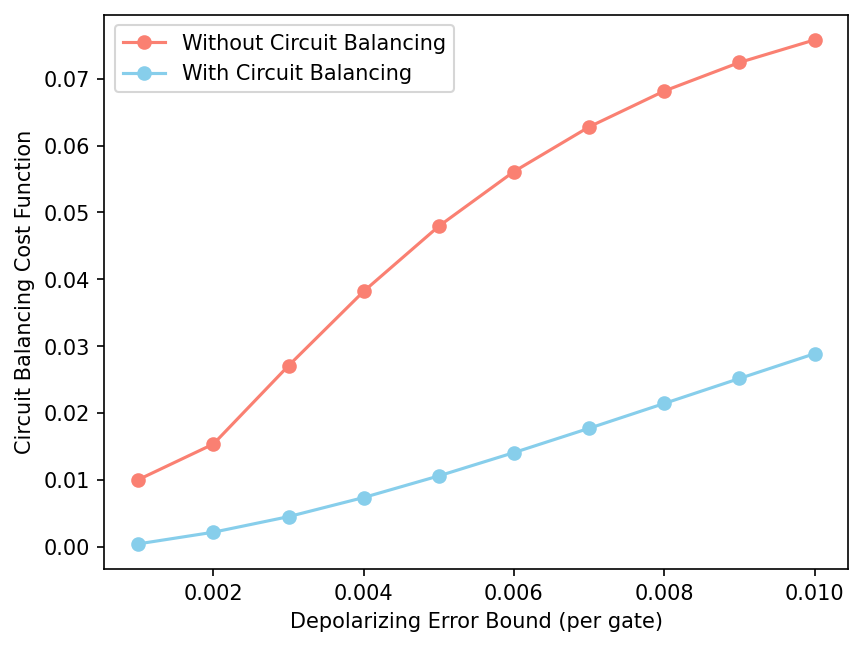

In [17]:
plt.figure(dpi=150)
plt.plot(error_ranges, all_default_costs, 'o-', color = 'salmon',  label='Without Circuit Balancing')
plt.plot(error_ranges, [np.mean(cost) for cost in all_costs], 'o-', color = 'skyblue',  label='With Circuit Balancing')

plt.xlabel('Depolarizing Error Bound (per gate)')
plt.ylabel('Circuit Balancing Cost Function')
plt.legend()
